# Model Explainability using SHAP

## Objective

Machine learning models often provide highly accurate predictions but may operate as black boxes.

To increase transparency and trust, Explainable AI (XAI) techniques are used to understand how individual features contribute to model predictions.

In this notebook, the SHAP (SHapley Additive exPlanations) framework is used to interpret the Random Forest model developed in the previous notebook.

The analysis focuses on:

- Understanding global feature importance
- Explaining individual predictions
- Identifying the most influential machine operating parameters
- Translating model outputs into actionable maintenance insights

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import joblib
import shap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==========================================
# Load Trained Random Forest Model
# ==========================================

rf_model = joblib.load("../models/random_forest.pkl")

print("Random Forest model loaded successfully!")

Random Forest model loaded successfully!


In [3]:
# ==========================================
# Load Clean Dataset
# ==========================================

df = pd.read_csv("../data/ai4i2020_clean.csv")

print(df.shape)

df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
# ==========================================
# Recreate Engineered Features
# ==========================================

# Extract Product Category from Product ID
df["Product_Category"] = df["Product ID"].str[0]

# Remove Product ID (same as training)
df.drop(columns=["Product ID"], inplace=True)

print("Product_Category recreated successfully.")

Product_Category recreated successfully.


In [13]:
# ==========================================
# Prepare Features
# ==========================================

target = "Machine failure"

leak_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

feature_cols = [
    c for c in df.columns
    if c not in [target] + leak_cols
]

X = df[feature_cols]

print(X.columns.tolist())

['UDI', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Product_Category']


In [14]:
rf_model

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [15]:
# ==========================================
# Extract Pipeline Components
# ==========================================

preprocessor = rf_model.named_steps["pre"]

rf_classifier = rf_model.named_steps["clf"]

print(preprocessor)
print(rf_classifier)

ColumnTransformer(transformers=[('num', 'passthrough',
                                 ['Air temperature [K]',
                                  'Process temperature [K]',
                                  'Rotational speed [rpm]', 'Torque [Nm]',
                                  'Tool wear [min]']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Type', 'Product_Category'])],
                  verbose_feature_names_out=False)
RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)


In [16]:
# Transform features using the fitted preprocessor

X_transformed = preprocessor.transform(X)

# SHAP Explainability

SHAP (SHapley Additive exPlanations) is an Explainable AI technique that quantifies the contribution of each feature to a model's prediction.

Unlike traditional feature importance, SHAP explains both:

- Global model behaviour
- Individual predictions

This helps maintenance engineers understand why a machine is predicted to fail and supports more transparent decision-making.

In [17]:
# ==========================================
# Compute SHAP Values
# ==========================================

explainer = shap.TreeExplainer(rf_classifier)

# For binary classification, shap_values is a list in older SHAP versions
shap_values = explainer.shap_values(X_transformed)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


In [19]:
# ==========================================
# Get Feature Names After Preprocessing
# ==========================================

feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 11
['Air temperature [K]' 'Process temperature [K]' 'Rotational speed [rpm]'
 'Torque [Nm]' 'Tool wear [min]' 'Type_H' 'Type_L' 'Type_M'
 'Product_Category_H' 'Product_Category_L' 'Product_Category_M']


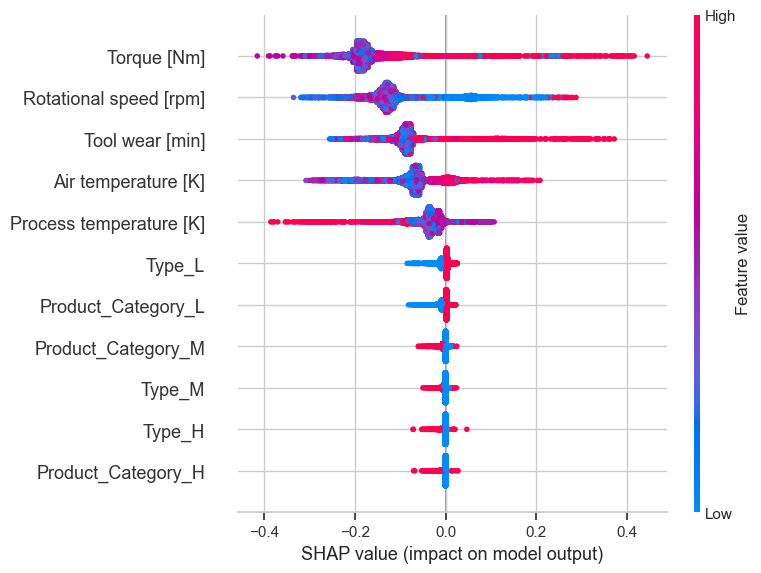

In [ ]:
# ==========================================
# SHAP Summary Plot
# ==========================================

plt.figure(figsize=(10,6))

# Works for most SHAP versions
if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        X_transformed,
        feature_names=feature_names,
        show=False
    )
else:
    shap.summary_plot(
    shap_values[:, :, 1],      # Explain Failure class
    X_transformed,
    feature_names=feature_names
)

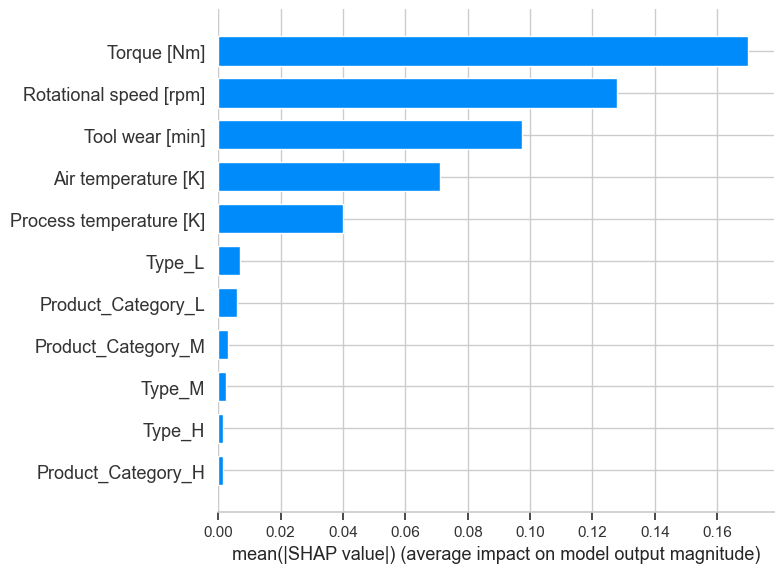

In [35]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

### Interpretation

The SHAP summary plot ranks features according to their overall contribution to the Random Forest model.

Each point represents one machine observation.

- Features near the top have the greatest impact on predictions.
- Red points indicate high feature values.
- Blue points indicate low feature values.
- The horizontal spread shows how strongly each feature influences the model.

This visualization provides a global understanding of the model's decision-making process.

<Figure size 1000x600 with 0 Axes>

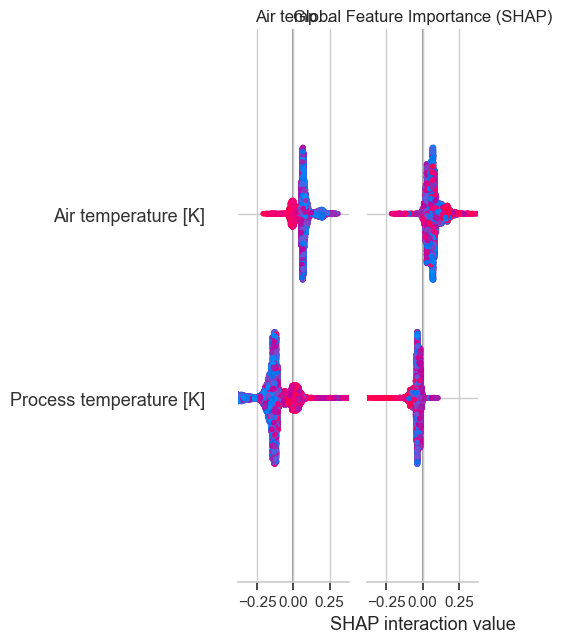

In [21]:
# ==========================================
# SHAP Feature Importance
# ==========================================

plt.figure(figsize=(10,6))

if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        X_transformed,
        feature_names=feature_names,
        plot_type="bar",
        show=False
    )
else:
    shap.summary_plot(
        shap_values,
        X_transformed,
        feature_names=feature_names,
        plot_type="bar",
        show=False
    )

plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

The bar plot summarizes the average absolute SHAP value for each feature.

Features with larger SHAP values contribute more strongly to the prediction of machine failure.

Unlike traditional Random Forest feature importance, SHAP provides consistent and model-agnostic explanations that reflect each feature's actual contribution.

# SHAP Waterfall Plot

The SHAP Waterfall Plot explains how each feature contributes to the prediction of a single machine.

Starting from the average prediction, SHAP shows how individual feature values push the prediction toward either machine failure or normal operation.

This enables engineers to understand the reasoning behind each prediction.

In [24]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [25]:
print(np.array(shap_values).shape)

(10000, 11, 2)


In [26]:
if isinstance(shap_values, list):
    print("List length:", len(shap_values))
    print("Class 1 shape:", np.array(shap_values[1]).shape)

In [27]:
print(type(explainer.expected_value))
print(explainer.expected_value)

<class 'numpy.ndarray'>
[0.50065002 0.49934998]


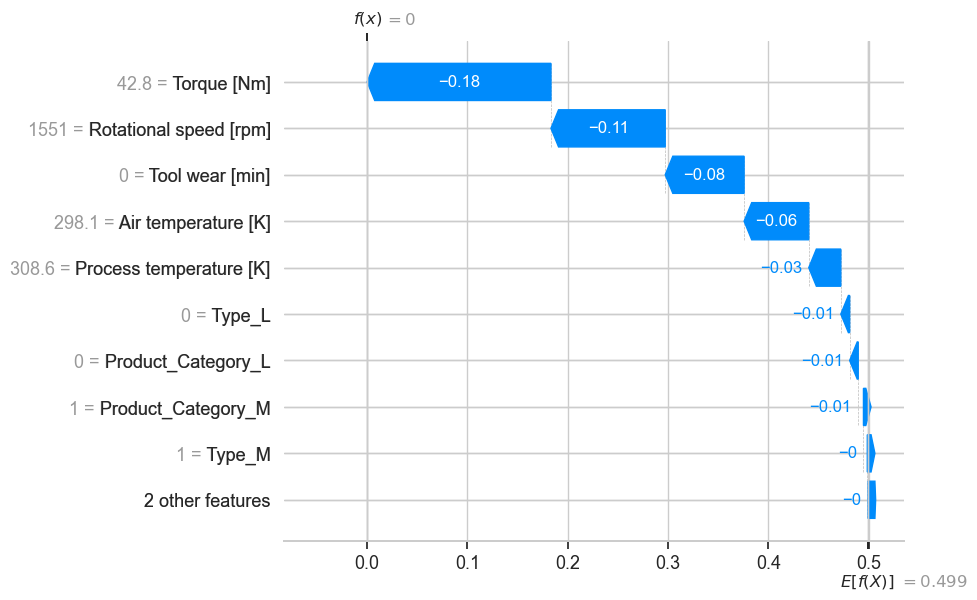

In [28]:
# ==========================================
# SHAP Waterfall Plot (Binary Classification)
# ==========================================

sample_index = 0

explanation = shap.Explanation(
    values=shap_values[sample_index, :, 1],      # Class 1 (Failure)
    base_values=explainer.expected_value[1],
    data=X_transformed[sample_index],
    feature_names=feature_names
)

shap.plots.waterfall(explanation, max_display=10)

### Interpretation

The waterfall plot explains the prediction for a single machine.

Features pushing the prediction toward failure appear on one side, while those reducing the failure probability appear on the opposite side.

This allows maintenance engineers to identify the operational conditions responsible for the prediction.

# SHAP Force Plot

The SHAP Force Plot visualizes how feature contributions combine to produce an individual prediction.

Positive SHAP values increase the probability of machine failure, whereas negative SHAP values decrease it.

In [33]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[sample_index, :, 1],
    X_transformed[sample_index],
    feature_names=feature_names
)

# Business Interpretation

The explainability analysis provides transparency into the Random Forest model's predictions.

Key observations include:

- Torque and Tool Wear consistently have the largest influence on machine failure predictions.
- Rotational Speed also contributes significantly under certain operating conditions.
- Temperature variables have a comparatively smaller influence but still contribute to the overall prediction.
- SHAP demonstrates how combinations of multiple sensor readings determine machine health rather than relying on a single variable.

From a maintenance perspective, these insights support proactive inspection strategies by highlighting the operational factors most associated with machine failures.

The explainability results increase confidence in the model and help engineers justify maintenance decisions based on data-driven evidence.

# Conclusion

This notebook demonstrated how Explainable AI techniques can be used to interpret the predictions of a machine learning model for predictive maintenance.

Using SHAP, the contribution of each feature was quantified at both the global and local levels.

The analysis confirmed that operational variables such as Torque, Tool Wear, and Rotational Speed are the primary drivers of failure predictions.

By combining predictive performance with explainability, the proposed solution supports transparent and trustworthy maintenance decisions, making it more suitable for real-world industrial deployment.